In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import torch

from models.simple_vae import VAE


In [39]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mutual_info_score
from abc import ABC, abstractmethod
import numpy as np
from scipy.stats import entropy

class DisentanglementMetric(ABC):
    def __init__(self, model):
        self.model = model

    def compute_entropy(self, x, num_bins=30):
        counts, _ = np.histogram(x, bins=num_bins)
        return entropy(counts)

    def mutual_information(self, x, y, num_bins=30):
        counts_xy, _, _ = np.histogram2d(x, y, bins=num_bins)
        counts_x, _ = np.histogram(x, bins=num_bins)
        counts_y, _ = np.histogram(y, bins=num_bins)
        H_x = self.compute_entropy(counts_x)
        H_y = self.compute_entropy(counts_y)
        H_xy = self.compute_entropy(counts_xy.flatten())
        return H_x + H_y - H_xy

    @abstractmethod
    def compute(self, data):
        pass


class MIG(DisentanglementMetric):
    def compute(self, data):
        latent_vars = self.model.encode(data).detach().cpu().numpy()
        factors = data.detach().cpu().numpy()
        MIG_score = 0
        for i in range(latent_vars.shape[1]):
            MI = [self.mutual_information(
                latent_vars[:, i], factors[:, j]) for j in range(factors.shape[1])]
            MI.sort(reverse=True)
            MIG_score += MI[0] - MI[1]
        return MIG_score / latent_vars.shape[1]



class DCI(DisentanglementMetric):
    def disentanglement_per_code(self, importance_matrix):
        return 1. - entropy(importance_matrix.T + 1e-11,
                            base=importance_matrix.shape[1])

    def completeness_per_factor(self, importance_matrix):
        return 1. - entropy(importance_matrix + 1e-11,
                            base=importance_matrix.shape[0])

    def compute(self, data):
        # Ensure the data is in the correct format (numpy arrays)
        latent_vars = self.model.encode(data).detach().cpu().numpy()
        factors = data.detach().cpu().numpy()   

        # Encode the data using the model's encoder

        num_factors = factors.shape[1]
        num_codes = latent_vars.shape[1]
        importance_matrix = np.zeros(shape=[num_codes, num_factors],
                                     dtype=np.float64)

        for i in range(num_factors):
            model = GradientBoostingClassifier()
            model.fit(latent_vars, factors[:, i])
            importance_matrix[:, i] = model.feature_importances_

        per_code = self.disentanglement_per_code(importance_matrix)
        code_importance = importance_matrix.sum(axis=1) / importance_matrix.sum()

        disentanglement_score = np.sum(per_code * code_importance)

        per_factor = self.completeness_per_factor(importance_matrix)
        factor_importance = importance_matrix.sum(axis=0) / importance_matrix.sum()

        completeness_score = np.sum(per_factor * factor_importance)

        return disentanglement_score, completeness_score


class Modularity(DisentanglementMetric):
    def compute(self, data):
        latent_vars = self.model.encode(data).detach().cpu().numpy().T
        factors = data.detach().cpu().numpy().T
        mutual_information = self.discrete_mutual_info(factors, latent_vars)
        modularity_score = self.modularity(mutual_information)
        return modularity_score

    def modularity(self, mutual_information):
        """Computes the modularity from mutual information."""
        squared_mi = np.square(mutual_information)
        max_squared_mi = np.max(squared_mi, axis=1)
        numerator = np.sum(squared_mi, axis=1) - max_squared_mi
        denominator = max_squared_mi * (squared_mi.shape[1] - 1.)
        delta = numerator / denominator
        modularity_score = 1. - delta
        index = (max_squared_mi == 0.)
        modularity_score[index] = 0.
        return np.mean(modularity_score)
    

    def discrete_mutual_info(self, factors, latent_vars):
        """Compute discrete mutual information."""
        num_codes = latent_vars.shape[0]
        num_factors = factors.shape[0]
        m = np.zeros([num_codes, num_factors])
        for i in range(num_codes):
          for j in range(num_factors):
            m[i, j] = mutual_info_score(factors[j, :], latent_vars[i, :])
        return m

In [40]:
n_samples = 10000
mean = np.array([-1, 0])
cov = np.array([[2, 0], [0, 1]])
data = torch.tensor(np.random.multivariate_normal(mean, cov, n_samples)).float()

/Users/maxpowers/miniconda3/envs/DL/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:64: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and continuous values for target
  warnings.warn(msg, UserWarning)
/Users/maxpowers/miniconda3/envs/DL/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:64: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and continuous values for target
  warnings.warn(msg, UserWarning)
/Users/maxpowers/miniconda3/envs/DL/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:64: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and continuous values for target
  warnings.warn(msg, UserWarning)
/Users/maxpowers/miniconda3/envs/DL/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:64: UserWarning: Clustering metrics expects discrete values but received cont

[[0.07168385048426806, 0.012235795792064241, 0.04577016953632507, 0.044419817602430856, 0.09639433706796297, 0.1450900785237541, 0.18457837286316536, 0.19523655866186362, 0.19955285472642625, 0.23642103211594523, 0.21943359484633773, 0.2753381001827453, 0.24037669854764654, 0.2428228507502752, 0.27350222778281275, 0.29103277228326285, 0.32754939340527245, 0.265874857896474, 0.28624114488857666, 0.28435626434355354, 0.3100981037549728, 0.3530296000758517, 0.2973035067002765, 0.3196516875560367, 0.2450132918236103, 0.36799683606258893, 0.36180039657291996, 0.38715865139464767, 0.3408431139285588, 0.3812720645552401, 0.44101288572833086, 0.45226630406235446, 0.41272953117040534, 0.46380051835504665, 0.434163519620296, 0.44270602812362614, 0.5424472032990739, 0.4734981906192137, 0.4489007353001415, 0.5313300297711874, 0.5282443992067338, 0.5116654058177448, 0.42783045932807573, 0.49038353730903483, 0.5331803456725446, 0.5265605947822511, 0.4876015799071922, 0.5188718887796115, 0.4668175840

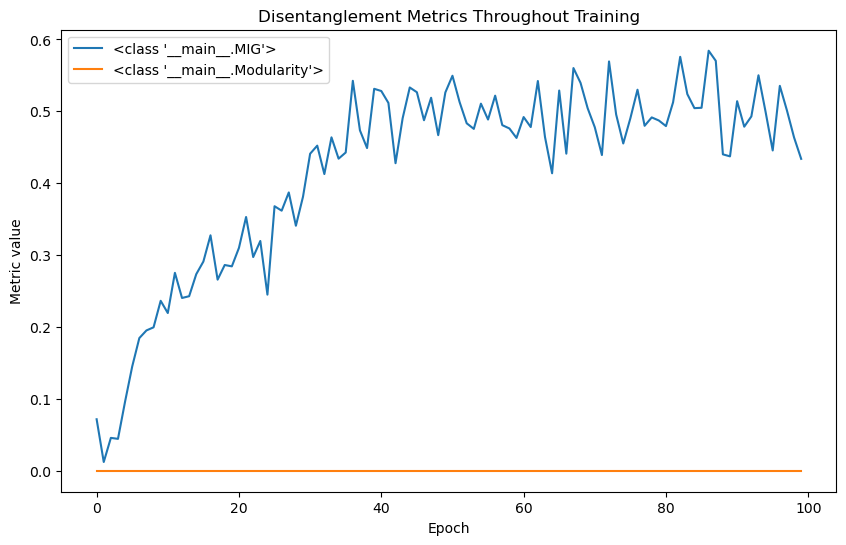

In [44]:
model_dir = './results/saved_models/simple_vae'

def representation_function(data):
    model.eval()
    with torch.no_grad():
        return model.encoder(data)[0].numpy()  # Modify this based on your model's architecture


metrics = [MIG, Modularity]
metric_values = [[] for _ in metrics]

epochs = 100
model = VAE(2, 2)

for epoch in range(0, epochs):
    model_file = os.path.join(model_dir, f'model_{epoch}.pt')
    model.load_state_dict(torch.load(model_file))
    model.eval()

    # Evaluate each metric
    for indx, metric in enumerate(metrics):
        score_dict = metric(model).compute(data)
        # Get the primary value from the score dictionary
        metric_values[indx].append(score_dict)
print(metric_values)
# Plot metrics
plt.figure(figsize=(10, 6))
x = np.arange(0, epochs)
for metric_name, metric_value in zip(metrics, metric_values):
    plt.plot(x, metric_value, label=metric_name)
plt.xlabel('Epoch')
plt.ylabel('Metric value')
plt.legend()
plt.title('Disentanglement Metrics Throughout Training')
plt.savefig('./results/metrics/metrics_plot.png')
